In [104]:
# First i have to think of these things in the EDA phase :
# is the data correct?
# is the "target" fine and balanced?
# how every column is distrbuted?
# what columns is different when dep = True and False?
# is there linked and related columns?
# is there Outliers?
# what we need for feature engineering?

# DATA LOADING & FIRST LOOK

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [106]:
# The dataset i will read here is about Student lifestyle and depression
dataset = pd.read_csv("student_lifestyle.csv")
dataset.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [107]:
# First we will start wirh EDA to understand the data given and searching for relationships and problems.
# Feature engineering--> creating new columns after noticing some good and useful relationships
# Encoding --> converting string columns into numbers before train the model but after understanding the data
# in EDA we will need to temporarly convert for "target" from True/False into 1/0 so we can calculates percentages and correlation.

In [108]:
# how big this data is:
dataset.shape
print("Rows:",dataset.shape[0])
print("Columns:",dataset.shape[1])

#the dataset contains 100000 students and 11 columns

Rows: 100000
Columns: 11


In [109]:
dataset.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'Department',
 'CGPA',
 'Sleep_Duration',
 'Study_Hours',
 'Social_Media_Hours',
 'Physical_Activity',
 'Stress_Level',
 'Depression']

In [110]:
# see the dataset in general "data types and missing values"
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [111]:
# just in case two values have same meaning we need to check every unique value the data has
# Categorical values
print(dataset["Gender"].unique())
print(dataset["Department"].unique())
print(dataset["Depression"].unique())

['Female' 'Male']
['Science' 'Engineering' 'Medical' 'Arts' 'Business']
[False  True]


In [112]:
# for example if it printed ['Female' 'Male' 'male' 'MALE' '  Male']
#strip() delete the space from start and the end
#lower() convert the letters to small letters
dataset["Gender"] = dataset["Gender"].str.strip().str.lower()
dataset["Department"] = dataset["Department"].str.strip().str.lower()



Male
M
man
Female
F
woman

In [113]:
gender_map = {

              "male": "Male",
              "m" : "Male",
              "man":"Male",

              "female":"Female",
              "f": "Female",
              "women": "Female"
}


dataset["Gender"] = ( dataset["Gender"].str.strip().str.lower().replace(gender_map) )

In [114]:
print(dataset["Gender"].value_counts(dropna=False))
print(dataset["Department"].value_counts(dropna=False))
print(dataset["Depression"].value_counts(dropna=False))


Gender
Male      50120
Female    49880
Name: count, dtype: int64
Department
science        20071
engineering    20057
arts           19998
medical        19964
business       19910
Name: count, dtype: int64
Depression
False    89938
True     10062
Name: count, dtype: int64


In [115]:
# Define column roles and the purpose of it
target = "Depression"
id_col  = "Student_ID"
print("Target:",target)
num_cols = dataset.select_dtypes(include=["int64","float64"]).columns.tolist()
print("Numerical columns:",num_cols)

cat_cols =dataset.select_dtypes(include=["object","category"]).columns.tolist()
print("Categorical colums:",cat_cols)

Target: Depression
Numerical columns: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Categorical colums: ['Gender', 'Department']


In [116]:
#  I will remove the ID from numerical columns because it is not a useful feature
# so the mean and min and max will not be affected with it

num_cols.remove(id_col)
print("Updated Numerical columns:",num_cols)

Updated Numerical columns: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


In [117]:
#check missing values:
dataset.isnull().sum()


,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


In [118]:
print(dataset.duplicated().sum())

0


In [119]:
#no dup but if there is :
dataset.drop_duplicates()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,arts,3.14,6.8,2.6,4.3,4,6,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,Female,medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,engineering,3.61,6.1,4.8,4.9,116,4,False


In [120]:
#just in case to not llet id column affect anything
print(dataset.drop(columns=[id_col]).duplicated().sum())

0


In [121]:
## Summary in statical way --> T transpose just to make the table easy to read
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,21.009010,2.000382,18.00,19.00,21.0,23.00,24.0
CGPA,100000.0,2.898316,0.532240,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,6.996425,1.498682,3.00,6.00,7.0,8.00,12.0
Study_Hours,100000.0,4.509517,1.976076,0.00,3.20,4.5,5.80,12.8
Social_Media_Hours,100000.0,3.503288,1.486852,0.00,2.50,3.5,4.50,10.0
Physical_Activity,100000.0,74.353180,43.366963,0.00,37.00,74.0,112.00,149.0
Stress_Level,100000.0,4.131660,1.424151,2.00,3.00,4.0,5.00,10.0


In [122]:
# now for categorical columns
dataset[cat_cols].describe().T



,count,unique,top,freq
Gender,100000,2,Male,50120
Department,100000,5,science,20071


In [123]:
print(dataset[cat_cols].value_counts(dropna=False))

Gender  Department 
Male    engineering    10099
Female  science        10099
Male    medical        10084
Female  arts           10007
Male    arts            9991
        business        9974
        science         9972
Female  engineering     9958
        business        9936
        medical         9880
Name: count, dtype: int64


In [124]:
for col in cat_cols:
   print("Column:" ,col)
   print(dataset[col].value_counts(dropna=False))

Column: Gender
Gender
Male      50120
Female    49880
Name: count, dtype: int64
Column: Department
Department
science        20071
engineering    20057
arts           19998
medical        19964
business       19910
Name: count, dtype: int64


In [125]:

print(dataset["Depression"].value_counts(dropna=False)) #na--> NaN --> missing value
#dropna = False --> don't hide it and print it with the rest
print(dataset["Depression"].value_counts(normalize=True) * 100)
# Class imbalance !! False values is much larger than True

Depression
False    89938
True     10062
Name: count, dtype: int64
Depression
False    89.938
True     10.062
Name: proportion, dtype: float64


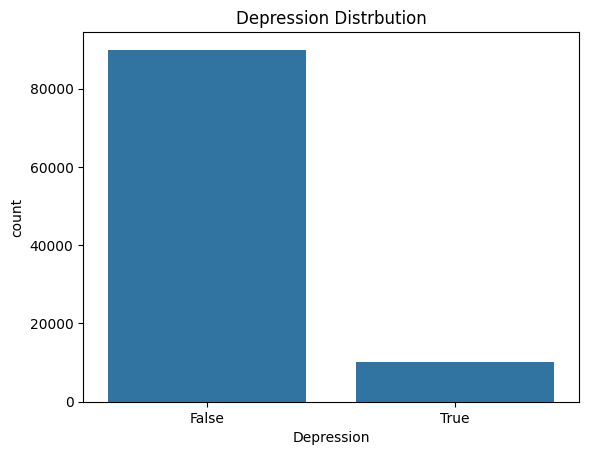

In [126]:
#plot the target distrbution
sns.countplot(data=dataset, x= "Depression")
plt.title("Depression Distrbution")
plt.show()

# we can understand from here most student are not depressed approx 90K of them
# but we need to fix it with propotions "stratify" so the model can learn better and not give as False as a result in every prediction because we still have 10K student are depressed

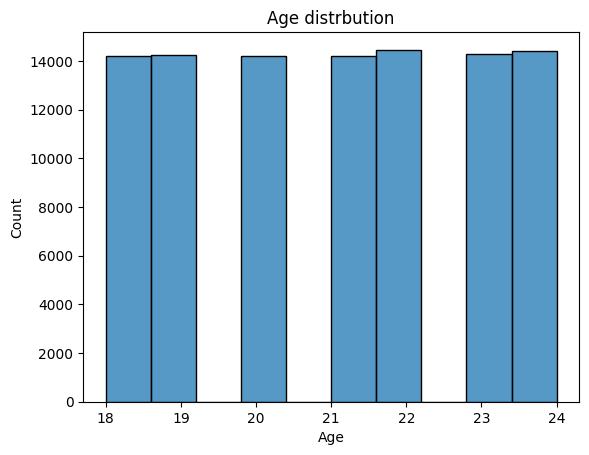

In [127]:
# lets start explore the first num column "age"
sns.histplot(data=dataset, x="Age", bins=10)

plt.title("Age distrbution")
plt.show()


#

In [128]:
print(dataset["Age"].value_counts().sort_index())
# the plot above now make sense, the number of students are near to each other tht why they distrbuted this way

Age
18    14197
19    14263
20    14193
21    14207
22    14462
23    14285
24    14393
Name: count, dtype: int64


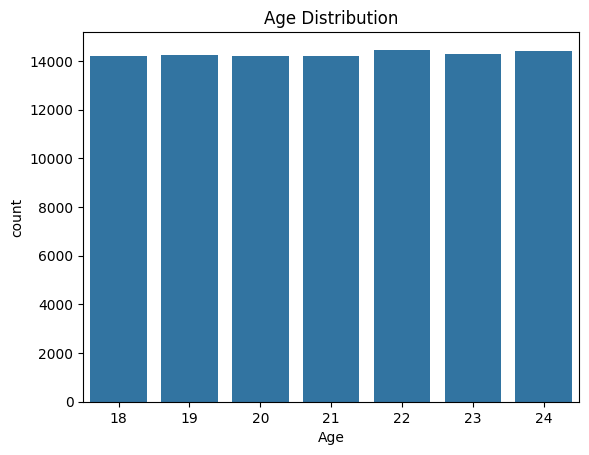

In [129]:
sns.countplot(data=dataset,x="Age")
plt.title("Age Distribution")
plt.show()
#Ages range from 18 to 24 and the number of students is almost equal for each age

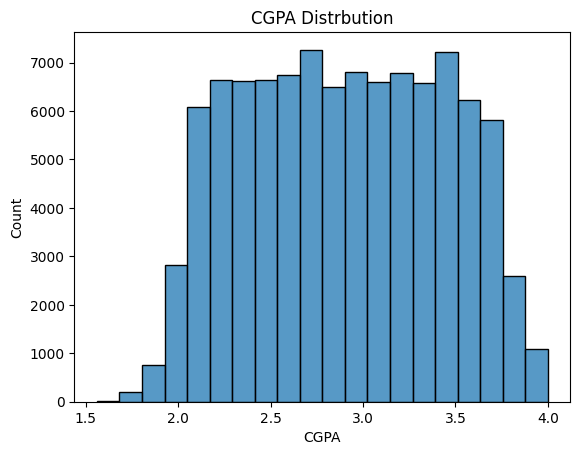

In [130]:
# now lets explore CGPA
sns.histplot(data=dataset,x="CGPA",bins=20)
plt.title("CGPA Distrbution")
plt.show()

#Most CGPA values are between around 2.1 and 3.7, while very low and very high values are less common.

In [131]:
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,21.009010,2.000382,18.00,19.00,21.0,23.00,24.0
CGPA,100000.0,2.898316,0.532240,1.56,2.45,2.9,3.35,4.0
Sleep_Duration,100000.0,6.996425,1.498682,3.00,6.00,7.0,8.00,12.0
Study_Hours,100000.0,4.509517,1.976076,0.00,3.20,4.5,5.80,12.8
Social_Media_Hours,100000.0,3.503288,1.486852,0.00,2.50,3.5,4.50,10.0
Physical_Activity,100000.0,74.353180,43.366963,0.00,37.00,74.0,112.00,149.0
Stress_Level,100000.0,4.131660,1.424151,2.00,3.00,4.0,5.00,10.0


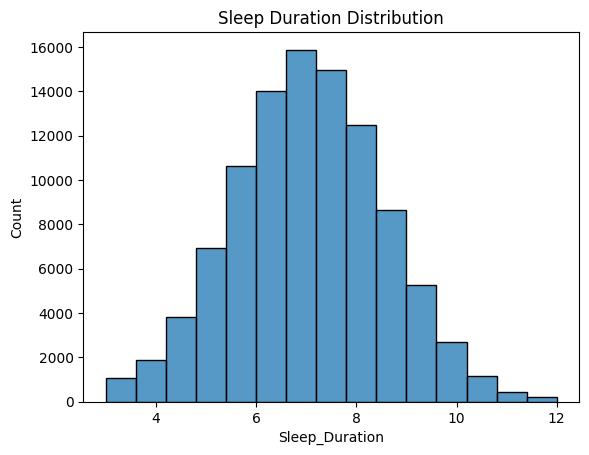

In [132]:
#now lets see sleep Duration
sns.histplot(data=dataset,x="Sleep_Duration",bins=15)
plt.title("Sleep Duration Distribution")
plt.show()
#Most students sleep around 7 hours, while very low and very high sleep durations are less common.

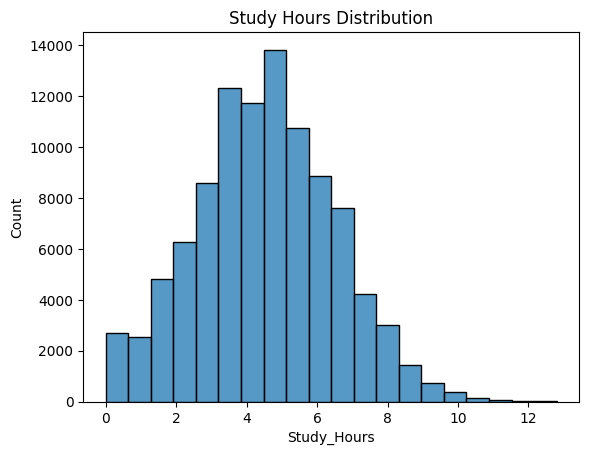

In [133]:
sns.histplot(data=dataset, x="Study_Hours", bins=20)

plt.title("Study Hours Distribution")
plt.show()
#Most students study around 3 to 7 hours, with the highest concentration around 4 to 5 hours. Very high study hours are less common here

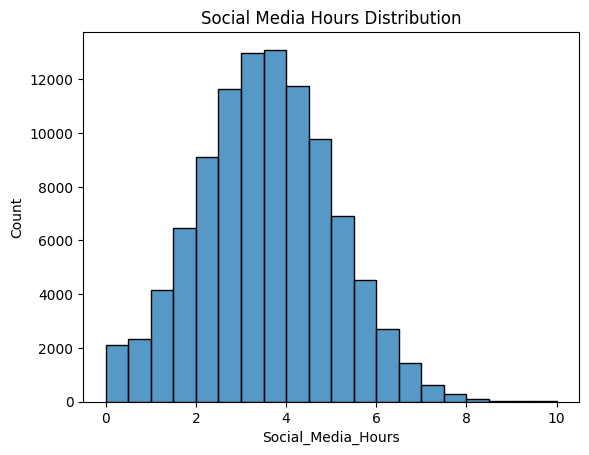

In [134]:
# explore Social Media Hours distribution
sns.histplot(data=dataset, x="Social_Media_Hours", bins=20)

plt.title("Social Media Hours Distribution")
plt.show()
#Most students spend around 2 to 5 hours on social media

In [135]:
# lets see physical act
print(dataset["Physical_Activity"].value_counts().sort_index())

Physical_Activity
0      620
1      673
2      645
3      639
4      676
      ... 
145    646
146    660
147    650
148    690
149    669
Name: count, Length: 150, dtype: int64


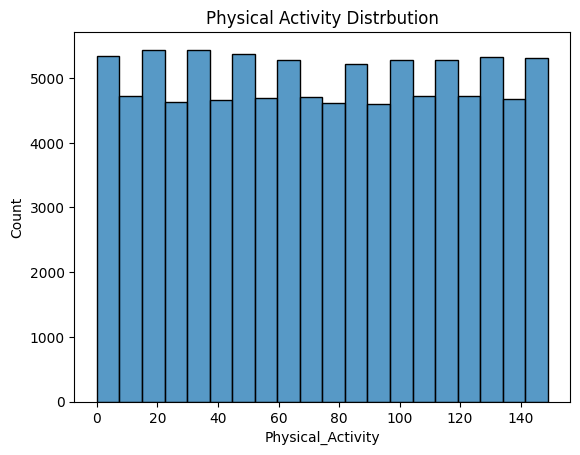

In [136]:
sns.histplot(data=dataset, x="Physical_Activity",bins=20)
plt.title("Physical Activity Distrbution")
plt.show()
#Uniform distribution --> The physical activity values are almost the same in all ranges.

In [137]:
print(dataset["Stress_Level"].value_counts().sort_index())

Stress_Level
2     13591
3     22666
4     23326
5     24525
6     11653
7      2255
8      1506
9       474
10        4
Name: count, dtype: int64


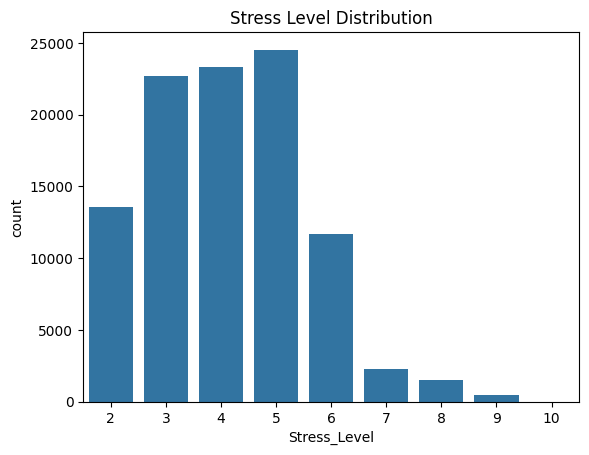

In [138]:
# see the stress levels
sns.countplot(data=dataset, x="Stress_Level")

plt.title("Stress Level Distribution")
plt.show()

# Most students have stress levels between 3 and 5. Level 5 is the most common.

In [139]:
# see the number of students in each gender
print(dataset["Gender"].value_counts())

Gender
Male      50120
Female    49880
Name: count, dtype: int64


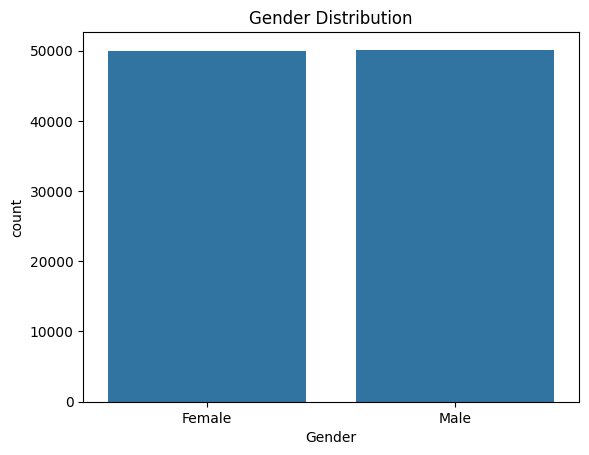

In [140]:
# plot Gender distribution
sns.countplot(data=dataset, x="Gender")

plt.title("Gender Distribution")
plt.show()
# The gender data is almost balanced

In [141]:
# see the number of students in each department
print(dataset["Department"].value_counts())

Department
science        20071
engineering    20057
arts           19998
medical        19964
business       19910
Name: count, dtype: int64


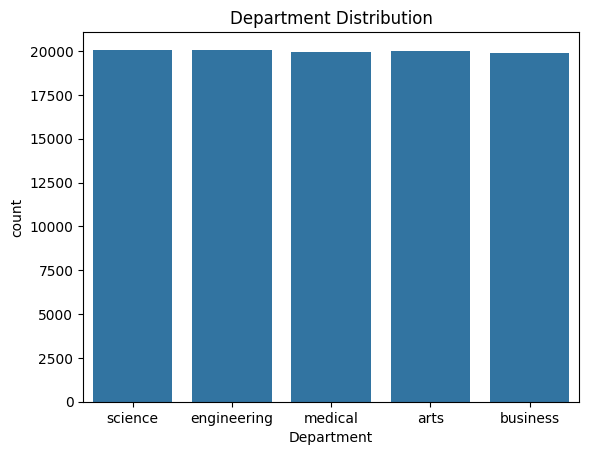

In [142]:
# plot Department distribution
sns.countplot(data=dataset, x="Department")

plt.title("Department Distribution")
plt.show()
# The number of students is almost equal in all departments.

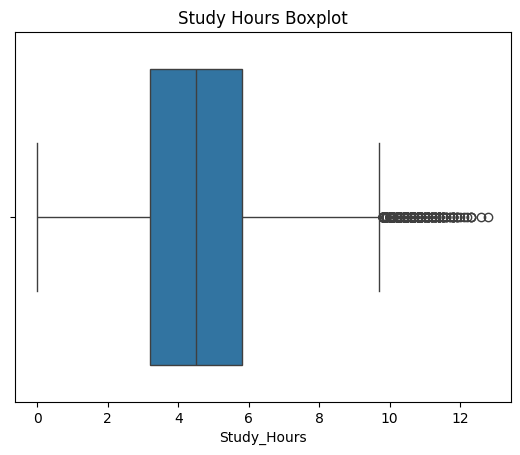

In [143]:
# check outliers in Study Hours
sns.boxplot(data=dataset, x="Study_Hours")

plt.title("Study Hours Boxplot")
plt.show()
# Most study hours are around 3 to 6 hours, and there are some high outliers.

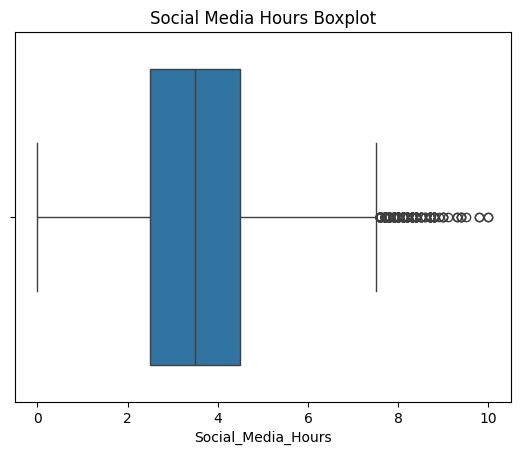

In [144]:
# check outliers in Social Media Hours
sns.boxplot(data=dataset, x="Social_Media_Hours")

plt.title("Social Media Hours Boxplot")
plt.show()
# Most students use social media around 2 to 5 hours, with some high outliers

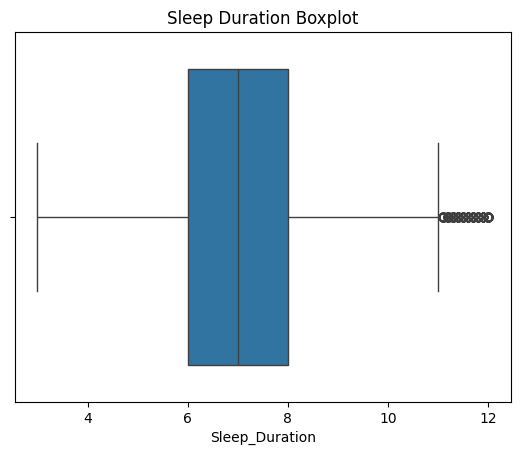

In [145]:
# check outliers in Sleep Duration
sns.boxplot(data=dataset, x="Sleep_Duration")

plt.title("Sleep Duration Boxplot")
plt.show()
# Most students sleep around 6 to 8 hours, with some high outliers

In [146]:
corr = dataset.drop(columns="Student_ID").corr(numeric_only=True)
print(corr["Depression"].sort_values())

CGPA                 -0.178971
Sleep_Duration       -0.057529
Study_Hours          -0.015932
Physical_Activity    -0.013935
Age                  -0.007722
Social_Media_Hours    0.016771
Stress_Level          0.075866
Depression            1.000000
Name: Depression, dtype: float64


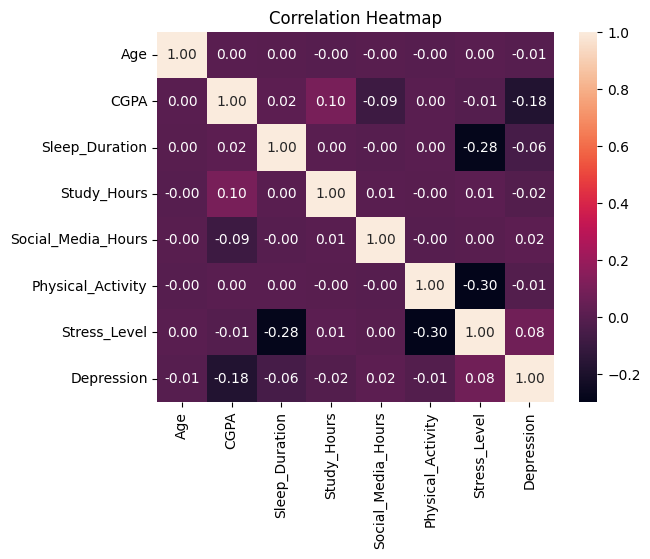

In [147]:
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
# CGPA has the strongest correlation with Depression, but it is still weak.
#CGPA = -0.18
#Stress_Level = 0.08
#Sleep_Duration = -0.06

In [148]:
#Student who sleep less than 6 hours
dataset["Low_Sleep"] = (dataset["Sleep_Duration"] < 6 ).astype(int)
#less than 6 hours -> 1
# 6 or more 0

In [149]:
#Student With high stress
dataset["high_Stress"] = (dataset["Stress_Level"] >=7).astype(int)


In [150]:
#delete ID from the dataset
dataset = dataset.drop(columns=["Student_ID"])

In [151]:
# now lets encode the categorical data we have , gender and department
dataset = pd.get_dummies(dataset, columns=["Gender","Department"], drop_first=False,dtype=int)

In [152]:
dataset.head()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Low_Sleep,high_Stress,Gender_Female,Gender_Male,Department_arts,Department_business,Department_engineering,Department_medical,Department_science
0,22,3.50,7.3,3.3,3.4,114,5,False,0,0,1,0,0,0,0,0,1
1,20,2.72,5.5,7.2,6.0,142,2,False,1,0,0,1,0,0,1,0,0
2,20,3.01,5.4,2.3,1.8,137,3,False,1,0,0,1,0,0,0,1,0
3,21,3.63,8.1,2.0,4.6,130,3,False,0,0,0,1,0,0,1,0,0
4,19,3.14,6.8,2.6,4.3,4,6,False,0,0,0,1,1,0,0,0,0


In [153]:
print(dataset.shape)

(100000, 17)


In [159]:
dataset[["Sleep_Duration","Low_Sleep","Stress_Level","high_Stress"]].head()

,Sleep_Duration,Low_Sleep,Stress_Level,high_Stress
0,7.3,0,5,0
1,5.5,1,2,0
2,5.4,1,3,0
3,8.1,0,3,0
4,6.8,0,6,0


In [158]:
print(dataset.columns.tolist())

['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression', 'Low_Sleep', 'high_Stress', 'Gender_Female', 'Gender_Male', 'Department_arts', 'Department_business', 'Department_engineering', 'Department_medical', 'Department_science']


In [160]:
#change target to 0 and 1
dataset["Depression"]= dataset["Depression"].astype(int)

In [161]:
dataset.head()

,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Low_Sleep,high_Stress,Gender_Female,Gender_Male,Department_arts,Department_business,Department_engineering,Department_medical,Department_science
0,22,3.50,7.3,3.3,3.4,114,5,0,0,0,1,0,0,0,0,0,1
1,20,2.72,5.5,7.2,6.0,142,2,0,1,0,0,1,0,0,1,0,0
2,20,3.01,5.4,2.3,1.8,137,3,0,1,0,0,1,0,0,0,1,0
3,21,3.63,8.1,2.0,4.6,130,3,0,0,0,0,1,0,0,1,0,0
4,19,3.14,6.8,2.6,4.3,4,6,0,0,0,0,1,1,0,0,0,0


In [162]:
#check no object left
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Age                     100000 non-null  int64  
 1   CGPA                    100000 non-null  float64
 2   Sleep_Duration          100000 non-null  float64
 3   Study_Hours             100000 non-null  float64
 4   Social_Media_Hours      100000 non-null  float64
 5   Physical_Activity       100000 non-null  int64  
 6   Stress_Level            100000 non-null  int64  
 7   Depression              100000 non-null  int64  
 8   Low_Sleep               100000 non-null  int64  
 9   high_Stress             100000 non-null  int64  
 10  Gender_Female           100000 non-null  int64  
 11  Gender_Male             100000 non-null  int64  
 12  Department_arts         100000 non-null  int64  
 13  Department_business     100000 non-null  int64  
 14  Department_engineerin

### EDA Insights

- The Depression target is not balance because most of the students have value 0 and only small number have value 1. Around 90% is no depression and around 10% is depression. This is important because the model can predict 0 many times and still get high accuracy, but maybe it is not really good for finding depression cases.

- The number of Male and Female students is almost same. This mean the gender column is balance and there is no one gender much bigger than the other gender in this dataset.

- The departments also have almost same number of students. Science, Engineering, Medical, Arts, and Business have around similar count, so there is no department that control most of the data.

- Most students sleep around 6 to 8 hours. Also most students study around 3 to 7 hours, and most social media hours are around 2 to 5 hours. There is some students with higher hours, but they are small number compared with the other students.

- Most stress levels are between 3 and 5, and level 5 is the most common value. After level 6, the number of students start become much smaller, especially for level 9 and 10.

- CGPA has the strongest correlation with Depression compared with the other numerical features, but the correlation is still weak and negative around -0.18. This mean when CGPA increase, Depression may decrease little, but the relation is not strong enough to say CGPA alone can explain Depression.

- There are some outliers in Study Hours, Social Media Hours, and Sleep Duration. I did not remove them because the values are still possible in real life. For example, some students may study or use social media for many hours, so the outlier does not always mean the value is wrong.

- In general, most features have weak correlation with Depression. This mean Depression may not depend on only one feature, and the model may need to use many features together to make the prediction.

In [164]:
#Seperate the features and target
X = dataset.drop(columns=["Depression"]) #seperate and get all features without dep
y = dataset["Depression"] # the target will be now dep as y

In [165]:
print("X:",X.shape)
print("y:",y.shape)

X: (100000, 16)
y: (100000,)


In [171]:
## split the data into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#here we used stratify because we noticed imbalanced data previously
#Depression
#False    89.938
#True     10.062


print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("Tain target:")
print(y_train.value_counts(normalize=True))

print("Test target:")
print(y_test.value_counts(normalize=True))

X_train: (80000, 16)
X_test: (20000, 16)
Tain target:
Depression
0    0.899375
1    0.100625
Name: proportion, dtype: float64
Test target:
Depression
0    0.8994
1    0.1006
Name: proportion, dtype: float64


In [173]:
#now Scale
from sklearn.preprocessing import StandardScaler

#scale the features:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #learn mean and median and variance then convert it to scaled numbers
X_test_scaled = scaler.transform(X_test) #  just scaling numbers

In [176]:
from sklearn.linear_model import LogisticRegression

#make the classification model
model = LogisticRegression(max_iter=1000,class_weight="balanced")
# class balanced to give the small classes more attention and importance
#train the model
model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [179]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[0 1 1 1 1 0 0 0 1 0]


In [180]:
# second model " decision tree "
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42,class_weight="balanced")

#train the model
tree_model.fit(X_train,y_train) #X_train and not the scaled one because decision tree does not need it

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [181]:
tree_pred = tree_model.predict(X_test)

In [185]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_estimators=100,random_state=42,class_weight="balanced",n_jobs=-1)# n_jobs=-1 means

#train the model
forest_model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [186]:
forest_pred = forest_model.predict(X_test)

In [188]:
print(forest_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


In [197]:
from sklearn.metrics import(    accuracy_score, precision_score,recall_score,f1_score)


log_acc= accuracy_score(y_test,y_pred)
log_precision = precision_score(y_test,y_pred)
log_recall = recall_score(y_test,y_pred)
log_f1 =f1_score(y_test,y_pred)


In [198]:

tree_acc= accuracy_score(y_test,tree_pred)
tree_precision = precision_score(y_test,tree_pred)
tree_recall = recall_score(y_test,tree_pred)
tree_f1 =f1_score(y_test,tree_pred)

In [199]:

forest_acc= accuracy_score(y_test,forest_pred)
forest_precision = precision_score(y_test,forest_pred)
forest_recall = recall_score(y_test,forest_pred)
forest_f1 =f1_score(y_test,forest_pred)

In [200]:
results = pd.DataFrame({


                        "Model": ["Logistic Regression","Decision Tree","Random Forest"],

                        "Accuracy":[log_acc,tree_acc,forest_acc],

                        "Precision" : [log_precision,tree_precision,forest_precision],

                        "Recall" : [log_recall,tree_recall,forest_recall],

                        "F1_Score" : [log_f1,tree_f1,forest_f1]


})

display(results)

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.62790,0.168498,0.685885,0.270535
1,Decision Tree,0.83670,0.179448,0.174453,0.176915
2,Random Forest,0.89945,0.507042,0.017893,0.034566


In [ ]:
# Logistic Regression has the best recall and F1 score.
# Random Forest has high accuracy, but it misses most depression cases.

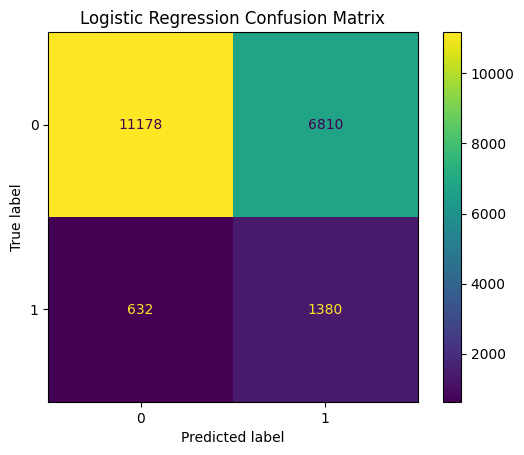

In [203]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=[0, 1]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

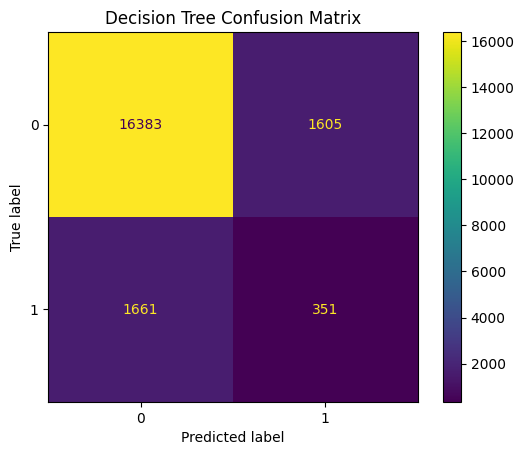

In [204]:
cm_tree = confusion_matrix(y_test, tree_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[0, 1]
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

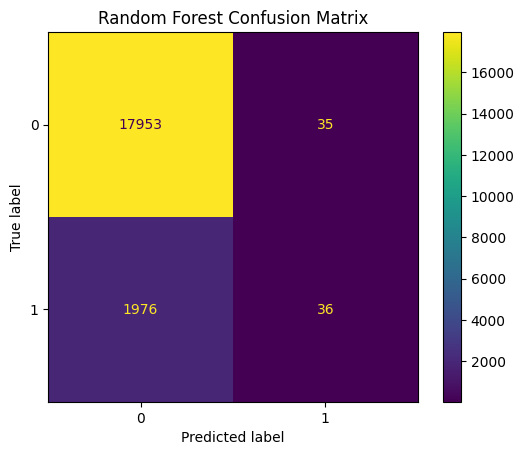

In [205]:
cm_forest = confusion_matrix(y_test, forest_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_forest,
    display_labels=[0, 1]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [206]:
#for PCA we will use scaled X train and test
from sklearn.decomposition import PCA
import numpy as np

#create PCA
pca =PCA()

#learn from train data and change it
X_train_pca = pca.fit_transform(X_train_scaled) #transform it into components

#change test data using the same pca
X_test_pca = pca.transform(X_test_scaled)


#Variance
print("Explained variance:",pca.explained_variance_ratio_)
# total variance
print("Cumulative variance:", np.cumsum(pca.explained_variance_ratio_))


# PCA takes many features and makes new columns like PC1, PC2 and PC3.
# It helps reduce the number of columns while keeping most of the data information


# The first 12 components keep around 95.6% of the data information
# PCA reduced the features from 16 to 12 components

Explained variance: [0.14361053 0.12501809 0.07827293 0.07816907 0.07815233 0.07809262
 0.07483807 0.07048926 0.06273447 0.06248373 0.05414037 0.05038954
 0.02676247 0.01684652 0.         0.        ]
Cumulative variance: [0.14361053 0.26862862 0.34690155 0.42507062 0.50322296 0.58131557
 0.65615364 0.7266429  0.78937737 0.8518611  0.90600147 0.95639101
 0.98315348 1.         1.         1.        ]


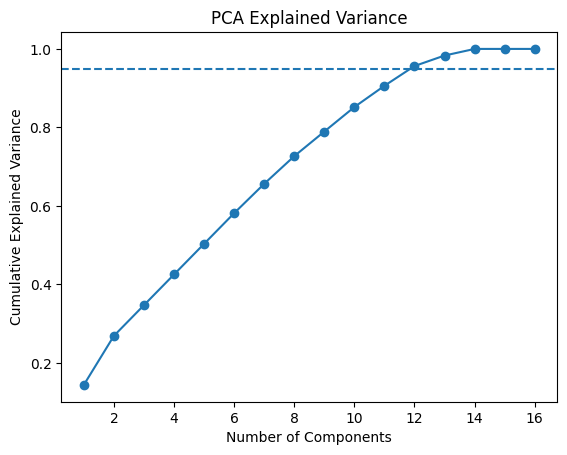

In [207]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.95, linestyle="--")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [212]:
# lets see how to explain 95% of the variance
pca=PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("features before pca:",X_train_scaled.shape[1])
print("components after pca:",X_train_pca.shape[1])
print("total explained variance:",pca.explained_variance_ratio_.sum())


features before pca: 16
components after pca: 12
total explained variance: 0.9563910106034058


In [213]:
# train Logistic Regression using PCA data
pca_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)

In [214]:
pca_acc = accuracy_score(y_test, y_pred_pca)
pca_precision = precision_score(y_test, y_pred_pca)
pca_recall = recall_score(y_test, y_pred_pca)
pca_f1 = f1_score(y_test, y_pred_pca)

print("Accuracy:", pca_acc)
print("Precision:", pca_precision)
print("Recall:", pca_recall)
print("F1 Score:", pca_f1)

Accuracy: 0.62565
Precision: 0.16725416312142943
Recall: 0.68389662027833
F1 Score: 0.26877624768043756


In [215]:
pca_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression with PCA"
    ],
    "Accuracy": [
        log_acc,
        pca_acc
    ],
    "Precision": [
        log_precision,
        pca_precision
    ],
    "Recall": [
        log_recall,
        pca_recall
    ],
    "F1_Score": [
        log_f1,
        pca_f1
    ]
})

display(pca_comparison)

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.62790,0.168498,0.685885,0.270535
1,Logistic Regression with PCA,0.62565,0.167254,0.683897,0.268776


In [ ]:
# PCA reduced the features from 16 to 12, but the model results became slightly lower.
# So PCA did not improve the Logistic Regression model!

In [217]:
#streamlit
import joblib

# save the best model
joblib.dump(model, "logistic_model.joblib")

# save the scaler
joblib.dump(scaler, "scaler.joblib")

# save the feature names and their order
joblib.dump(X.columns.tolist(), "feature_columns.joblib")

# save model results
results.to_csv("model_results.csv", index=False)

# save confusion matrices
confusion_matrices = {
    "Logistic Regression": cm_log,
    "Decision Tree": cm_tree,
    "Random Forest": cm_forest
}

joblib.dump(confusion_matrices, "confusion_matrices.joblib")

print("All files were saved.")

All files were saved.


In [218]:
import sklearn
import pandas
import numpy
import joblib
import matplotlib
import seaborn

print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)

scikit-learn: 1.6.1
pandas: 2.2.2
numpy: 2.0.2
joblib: 1.5.3
matplotlib: 3.10.0
seaborn: 0.13.2


In [220]:
import joblib


joblib.dump(tree_model, "decision_tree_model.joblib")
joblib.dump(forest_model, "random_forest_model.joblib")

print("All three models were saved.")

All three models were saved.


In [221]:
import joblib
import os

# save the same Random Forest model with compression
joblib.dump(
    forest_model,
    "random_forest_model.joblib",
    compress=3
)

file_size = os.path.getsize("random_forest_model.joblib") / (1024 ** 2)

print("File size:", round(file_size, 2), "MB")

File size: 34.47 MB


In [222]:
import joblib
import os

# save the same Random Forest model with strong compression
joblib.dump(
    forest_model,
    "random_forest_model.joblib",
    compress=("xz", 9)
)

size_mb = os.path.getsize("random_forest_model.joblib") / (1024 ** 2)

print("Compressed file size:", round(size_mb, 2), "MB")

Compressed file size: 13.99 MB


Three classification models were tested: Logistic Regression, Decision Tree, and Random Forest.

Random Forest had the highest accuracy, but it detected only a very small number of the real depression cases. This happened because the target classes were imbalanced.

Logistic Regression was the best model because it had the highest recall and F1 score. It detected more of the students who had depression.

PCA reduced the features from 16 to 12 and kept around 95.6% of the variance, but it slightly reduced the model performance, so it did not help in this project.

With more time, I would try model tuning, different prediction thresholds, cross-validation, and methods for handling the class imbalance.

1. Import libraries
2. Load the dataset ->
**pd.read_csv("student_lifestyle.csv")**
3. Display the first rows --> **dataset.head()**
4. Check the shape ---> **dataset.shape**
5. Display column names -->
**dataset.columns_tolist()**
6. Check data types --> **dataset.info()**
7. Check unique categorical values --> **dataset[""].unique()**
8. Define target, ID, numerical, and categorical columns --> **target = "Depression"** , **not_useful = dataset[""]** ,
**dataset.select_dtypes(include=["int64"]).columns.tolist()** , removed not useful -> **num_cols.remove(not_useful)**
9. Check missing values
10. Check duplicated rows
11. Display summary statistics
12. Check target balance
13. Plot target distribution